In [79]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [80]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [81]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def show_results(model, df_train_full, df_test, target_col, exog_cols, model_path):
    last_window = df_train_full[target_col].iloc[-len(model.lags):]
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols],
                last_window = last_window
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols],
            )
    return best_model

In [82]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [83]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

Глубина 0

In [84]:
depth = 0
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 19:52:19,624] A new study created in memory with name: no-name-925e2226-de7e-4cc9-bdaf-c5dcf444f510
[I 2026-05-10 19:52:19,994] Trial 0 finished with value: 4.04403722477439 and parameters: {'lags': 2, 'n_estimators': 709, 'learning_rate': 0.1552791961462864, 'max_depth': 8, 'subsample': 0.7114800809456003, 'colsample_bytree': 0.6406062369496391, 'colsample_bylevel': 0.45466506308094634, 'colsample_bynode': 0.548878380734775, 'reg_alpha': 4.334069768198051e-05, 'reg_lambda': 0.0016878158594537294, 'gamma': 0.008803842009868447, 'min_child_weight': 7, 'max_delta_step': 19}. Best is trial 0 with value: 4.04403722477439.
[I 2026-05-10 19:52:20,185] Trial 1 finished with value: 3.358183549153697 and parameters: {'lags': 1, 'n_estimators': 521, 'learning_rate': 0.021670123633848307, 'max_depth': 4, 'subsample': 0.8970736401955905, 'colsample_bytree': 0.6756102914861548, 'colsample_bylevel': 0.43593461860146554, 'colsample_bynode': 0.6025073739370216, 'reg_alpha': 2.77394037900

Лучшие параметры = {'lags': 1, 'n_estimators': 501, 'learning_rate': 0.049076257170929304, 'max_depth': 3, 'subsample': 0.9568812049134778, 'colsample_bytree': 0.6322556348757522, 'colsample_bylevel': 0.6511389446415572, 'colsample_bynode': 0.9502505199197157, 'reg_alpha': 0.08597286713047679, 'reg_lambda': 0.009157970556741462, 'gamma': 2.890212683388132e-05, 'min_child_weight': 10, 'max_delta_step': 14}
Лучший RMSE score = 3.3084392762588255


In [ ]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

RMSE на тесте = 2.755842187553672


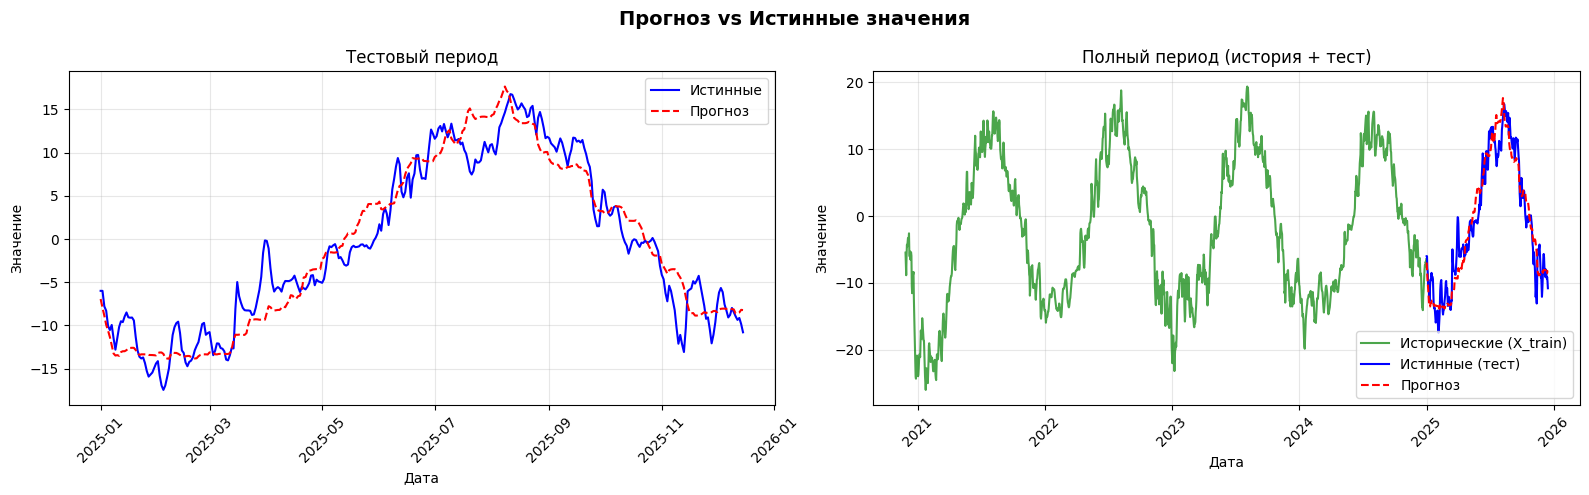

,feature,importance
2,Месяц_cos,0.467821
0,lag_1,0.319555
4,day_of_year_cos,0.105838
3,day_of_year_sin,0.067789
1,Месяц_sin,0.038997


In [85]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 3

In [86]:
depth = 3
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 20:30:44,386] A new study created in memory with name: no-name-ac547141-2b14-420b-a29f-a86ce7bfe540
[I 2026-05-10 20:30:44,886] Trial 0 finished with value: 1.6300985809634663 and parameters: {'lags': 4, 'n_estimators': 903, 'learning_rate': 0.003199530847714949, 'max_depth': 7, 'subsample': 0.6143263174666809, 'colsample_bytree': 0.9051253666639233, 'colsample_bylevel': 0.8719351871366579, 'colsample_bynode': 0.41764632920901285, 'reg_alpha': 0.00011107081899674678, 'reg_lambda': 0.2625329384856505, 'gamma': 0.1207583298809066, 'min_child_weight': 3, 'max_delta_step': 6}. Best is trial 0 with value: 1.6300985809634663.
[I 2026-05-10 20:30:45,053] Trial 1 finished with value: 2.926850308717145 and parameters: {'lags': 5, 'n_estimators': 234, 'learning_rate': 0.00052083471263128, 'max_depth': 1, 'subsample': 0.8367359504656169, 'colsample_bytree': 0.6567577669495088, 'colsample_bylevel': 0.8086708467858246, 'colsample_bynode': 0.9570403516264169, 'reg_alpha': 0.00289762843

Лучшие параметры = {'lags': 4, 'n_estimators': 443, 'learning_rate': 0.2192150997811477, 'max_depth': 6, 'subsample': 0.9990467087801224, 'colsample_bytree': 0.5153418316255709, 'colsample_bylevel': 0.5287431788095992, 'colsample_bynode': 0.661016594010853, 'reg_alpha': 0.028217258389328287, 'reg_lambda': 0.015939178223202472, 'gamma': 0.002935717584593165, 'min_child_weight': 2, 'max_delta_step': 14}
Лучший RMSE score = 0.704185033575573


In [ ]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

RMSE на тесте = 0.7886569710926575


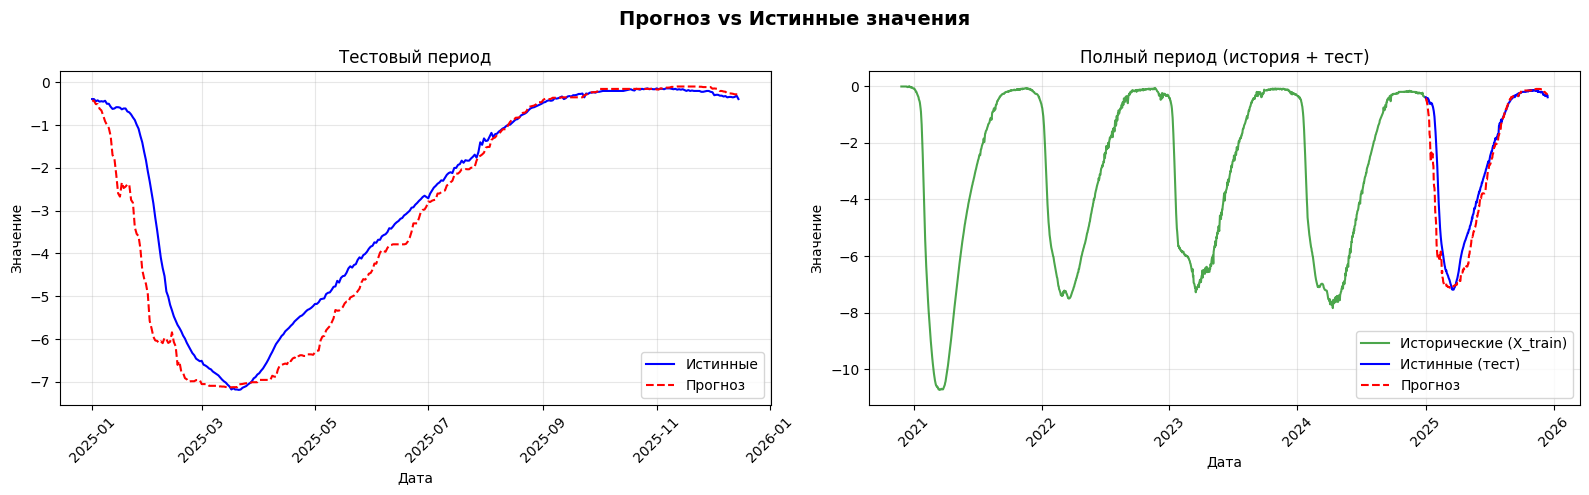

,feature,importance
4,Месяц_sin,0.309280
1,lag_2,0.279254
6,day_of_year_sin,0.157783
0,lag_1,0.117260
5,Месяц_cos,0.044066
7,day_of_year_cos,0.039035
3,lag_4,0.028807
2,lag_3,0.024515


In [87]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 5

In [88]:
depth = 5
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 19:52:40,613] A new study created in memory with name: no-name-2adb9cf8-9013-45ae-887a-235410ed45fd
[I 2026-05-10 19:52:40,750] Trial 0 finished with value: 0.6501440476432511 and parameters: {'lags': 5, 'n_estimators': 379, 'learning_rate': 0.04540610476538451, 'max_depth': 2, 'subsample': 0.6446687560550574, 'colsample_bytree': 0.5132615842226421, 'colsample_bylevel': 0.4310273512311118, 'colsample_bynode': 0.7823503632483776, 'reg_alpha': 4.47359893009421e-05, 'reg_lambda': 0.03467196156355101, 'gamma': 3.7822157750287517, 'min_child_weight': 11, 'max_delta_step': 1}. Best is trial 0 with value: 0.6501440476432511.
[I 2026-05-10 19:52:40,867] Trial 1 finished with value: 0.8965107933453534 and parameters: {'lags': 1, 'n_estimators': 241, 'learning_rate': 0.04513355808615637, 'max_depth': 7, 'subsample': 0.9446405051411705, 'colsample_bytree': 0.9618196992641171, 'colsample_bylevel': 0.4073264138354854, 'colsample_bynode': 0.8691467132765752, 'reg_alpha': 6.616431403077

Лучшие параметры = {'lags': 1, 'n_estimators': 908, 'learning_rate': 0.0728325597213494, 'max_depth': 7, 'subsample': 0.5948023762218041, 'colsample_bytree': 0.9070650271443647, 'colsample_bylevel': 0.8509631159413705, 'colsample_bynode': 0.587401277845904, 'reg_alpha': 2.279711625635748e-05, 'reg_lambda': 0.005475122383306498, 'gamma': 0.00935877039152085, 'min_child_weight': 8, 'max_delta_step': 2}
Лучший RMSE score = 0.644402812542121


In [ ]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

RMSE на тесте = 0.5390949468148316


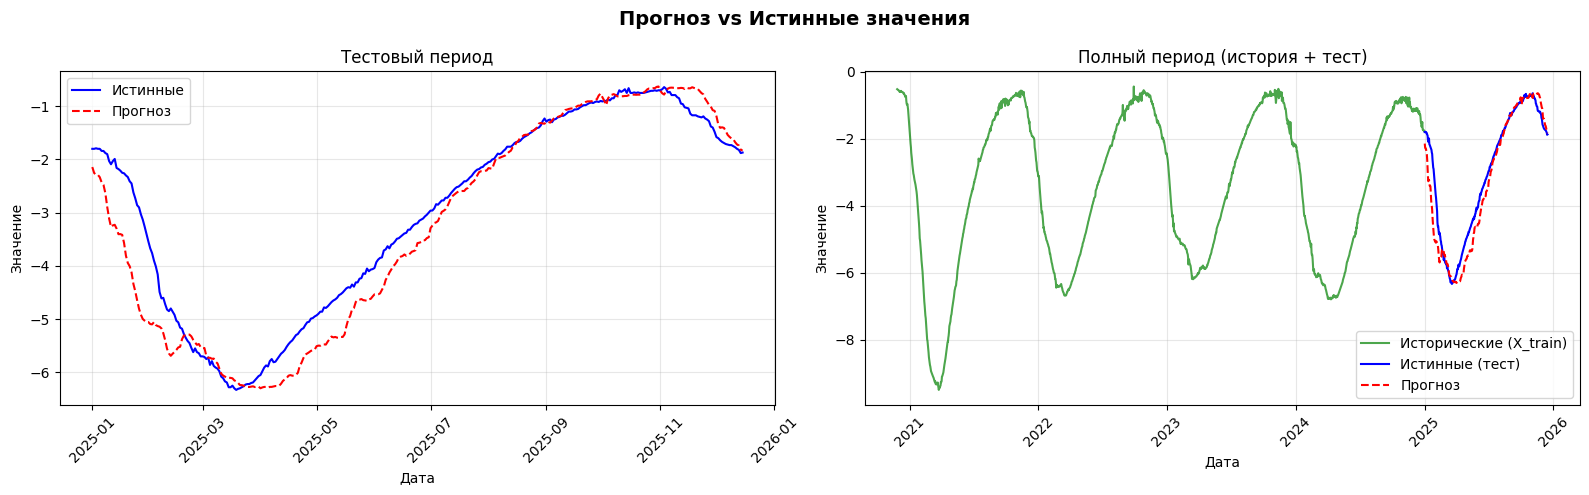

,feature,importance
1,Месяц_sin,0.349871
0,lag_1,0.326826
3,day_of_year_sin,0.193307
2,Месяц_cos,0.091608
4,day_of_year_cos,0.038387


In [89]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 7

In [90]:
depth = 7
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 20:29:14,088] A new study created in memory with name: no-name-1d8bb0f1-9ec8-45fa-93e9-4166cae1bb60
[I 2026-05-10 20:29:14,299] Trial 0 finished with value: 0.5821320121057815 and parameters: {'lags': 3, 'n_estimators': 995, 'learning_rate': 0.06501864521563731, 'max_depth': 9, 'subsample': 0.9441222622945408, 'colsample_bytree': 0.5062832345322247, 'colsample_bylevel': 0.7737869608052794, 'colsample_bynode': 0.7599017326204651, 'reg_alpha': 0.00026729618950079357, 'reg_lambda': 2.3390656618177212, 'gamma': 0.27689095265773805, 'min_child_weight': 6, 'max_delta_step': 5}. Best is trial 0 with value: 0.5821320121057815.
[I 2026-05-10 20:29:14,463] Trial 1 finished with value: 1.447807326019373 and parameters: {'lags': 1, 'n_estimators': 614, 'learning_rate': 0.0005855702388803829, 'max_depth': 2, 'subsample': 0.9005442958702232, 'colsample_bytree': 0.7120025449924374, 'colsample_bylevel': 0.8614704094758905, 'colsample_bynode': 0.4758704118209356, 'reg_alpha': 0.0266435549

Лучшие параметры = {'lags': 3, 'n_estimators': 664, 'learning_rate': 0.0229343239293905, 'max_depth': 10, 'subsample': 0.4472390260899367, 'colsample_bytree': 0.5263149984591071, 'colsample_bylevel': 0.7859789627322418, 'colsample_bynode': 0.6060162211908178, 'reg_alpha': 1.4133792961540761e-05, 'reg_lambda': 3.2435992762845764e-05, 'gamma': 1.4446203050737842, 'min_child_weight': 10, 'max_delta_step': 16}
Лучший RMSE score = 0.5495695553965615


In [ ]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

RMSE на тесте = 0.5039792552992048


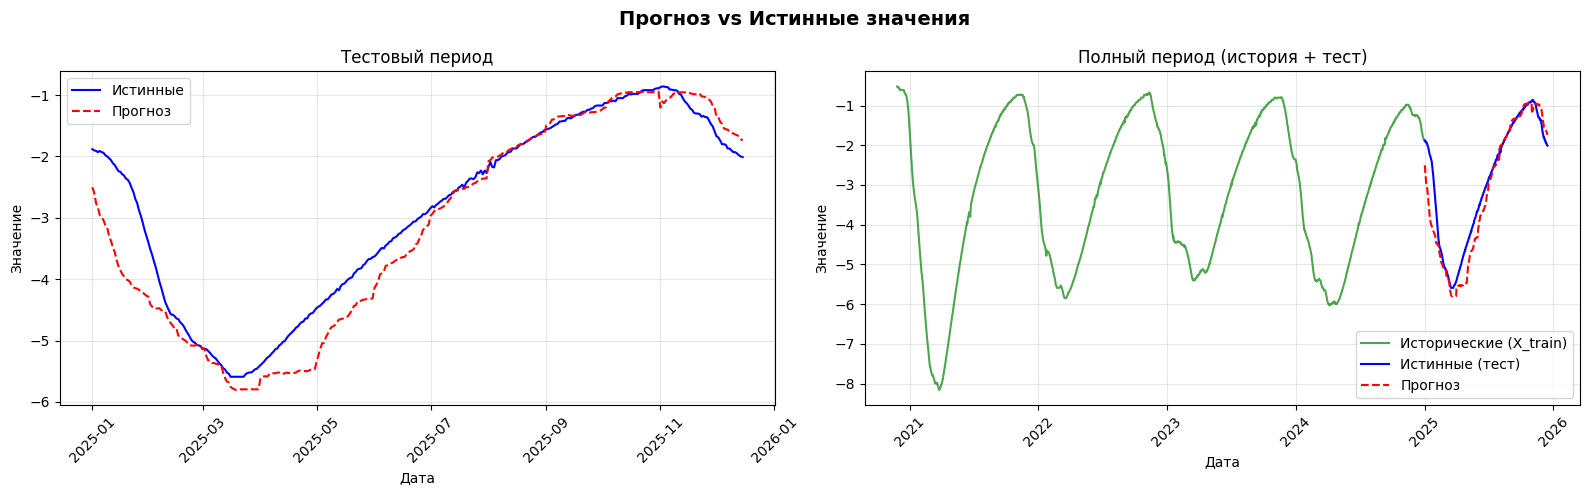

,feature,importance
5,day_of_year_sin,0.211346
3,Месяц_sin,0.196868
1,lag_2,0.179404
2,lag_3,0.172819
0,lag_1,0.123892
4,Месяц_cos,0.063684
6,day_of_year_cos,0.051987


In [91]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 10

In [92]:
depth = 10
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [ ]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 20:02:23,763] A new study created in memory with name: no-name-9642e853-c8b7-48c9-9fe9-c7129023dccb
[I 2026-05-10 20:02:24,048] Trial 0 finished with value: 0.8005410790035186 and parameters: {'lags': 3, 'n_estimators': 816, 'learning_rate': 0.0007631178597676466, 'max_depth': 3, 'subsample': 0.7435014312614909, 'colsample_bytree': 0.45692054730533493, 'colsample_bylevel': 0.8733625031205843, 'colsample_bynode': 0.42461021983034236, 'reg_alpha': 0.7641637992748178, 'reg_lambda': 3.006770244575968, 'gamma': 0.022283184728124843, 'min_child_weight': 4, 'max_delta_step': 9}. Best is trial 0 with value: 0.8005410790035186.
[I 2026-05-10 20:02:24,280] Trial 1 finished with value: 0.4092616925378611 and parameters: {'lags': 5, 'n_estimators': 307, 'learning_rate': 0.39934403624595066, 'max_depth': 10, 'subsample': 0.43538791429910007, 'colsample_bytree': 0.48728680775375893, 'colsample_bylevel': 0.47897407958917193, 'colsample_bynode': 0.5128324513497213, 'reg_alpha': 0.0298623

Лучшие параметры = {'lags': 3, 'n_estimators': 873, 'learning_rate': 0.27780011420424494, 'max_depth': 4, 'subsample': 0.653786022043521, 'colsample_bytree': 0.5643258234169817, 'colsample_bylevel': 0.8107453781015888, 'colsample_bynode': 0.7919851346055842, 'reg_alpha': 0.01091158912571786, 'reg_lambda': 0.00013606984847387748, 'gamma': 5.090568204477715e-05, 'min_child_weight': 3, 'max_delta_step': 2}
Лучший RMSE score = 0.3815256701188583


In [ ]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

RMSE на тесте = 0.17932403567834387


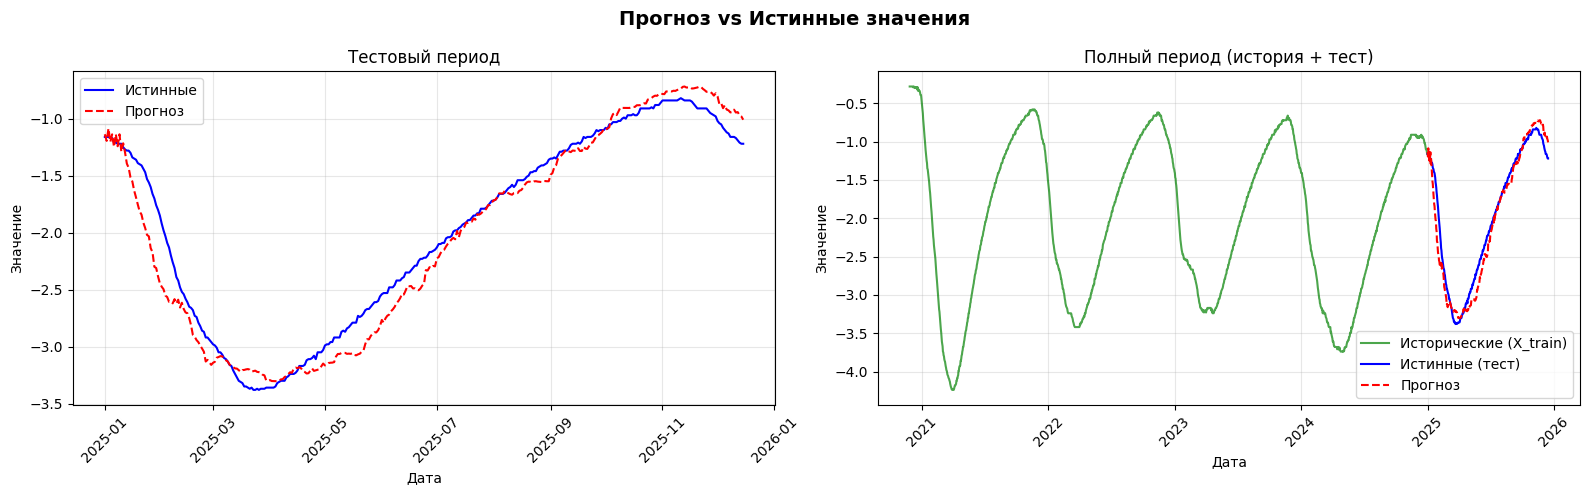

,feature,importance
1,lag_2,0.650524
5,day_of_year_sin,0.143486
0,lag_1,0.116456
4,Месяц_cos,0.033663
2,lag_3,0.027619
3,Месяц_sin,0.021800
6,day_of_year_cos,0.006451


In [93]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances